(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

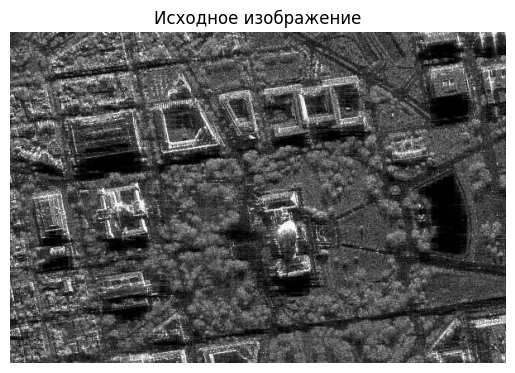

In [56]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from collections import Counter

image = cv2.imread("sar_1_gray.jpg", cv2.IMREAD_GRAYSCALE)
image = image.astype(np.float32)
np.savetxt("monochrome_image.txt", image, fmt='%d')

plt.title("Исходное изображение")
plt.imshow(image, cmap='gray')
plt.axis("off")

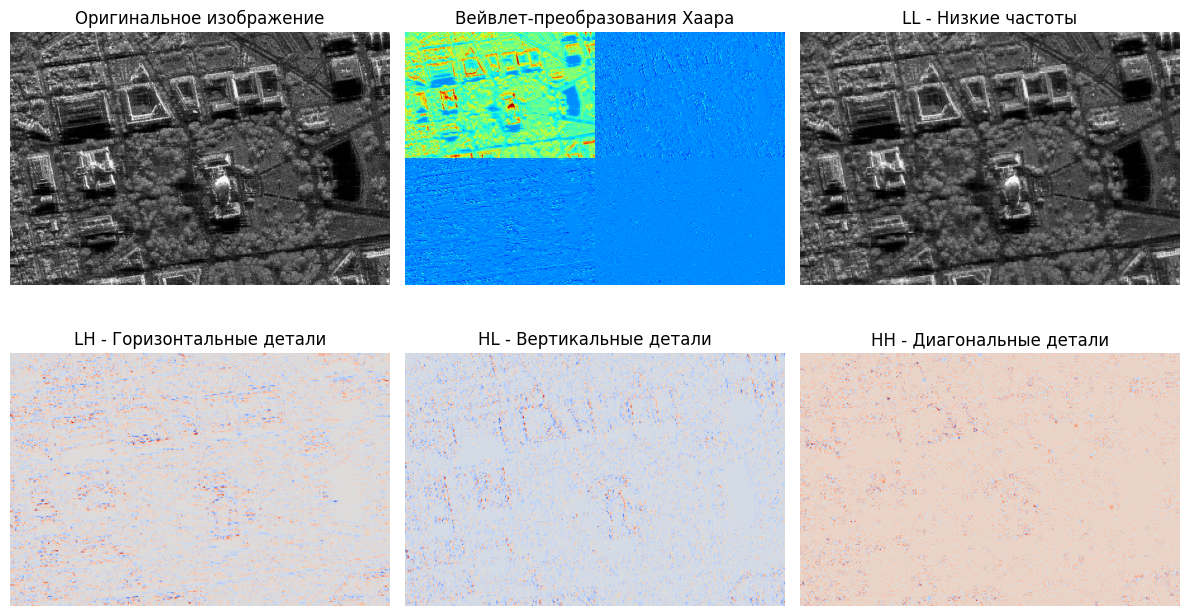

In [57]:
def haar_transform(image):
    height, width = image.shape
    temp = np.zeros_like(image)

    for i in range(height):
        for j in range(0, width, 2):
            if j + 1 < width:
                temp[i, j // 2] = (image[i, j] + image[i, j + 1]) / 2
                temp[i, j // 2 + width // 2] = (image[i, j] - image[i, j + 1]) / 2
            else:
                temp[i, j // 2] = image[i, j]

    result = np.zeros_like(temp)
    for j in range(width):
        for i in range(0, height, 2):
            if i + 1 < height:
                result[i // 2, j] = (temp[i, j] + temp[i + 1, j]) / 2
                result[i // 2 + height // 2, j] = (temp[i, j] - temp[i + 1, j]) / 2
            else:
                result[i // 2, j] = temp[i, j]

    ll = result[:height // 2, :width // 2]
    hl = result[height // 2:, :width // 2]
    lh = result[:height // 2, width // 2:]
    hh = result[height // 2:, width // 2:]

    return ll, hl, lh, hh, result


ll, lh, hl, hh, haar_image = haar_transform(image)

plt.figure(figsize=(12, 10))

plt.subplot(3, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(haar_image, cmap='jet')
plt.title('Вейвлет-преобразования Хаара')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(ll, cmap='gray')
plt.title('LL - Низкие частоты')
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(lh, cmap='coolwarm')
plt.title('LH - Горизонтальные детали')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(hl, cmap='coolwarm')
plt.title('HL - Вертикальные детали')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(hh, cmap='coolwarm')
plt.title('HH - Диагональные детали')
plt.axis('off')
plt.tight_layout()
plt.show()

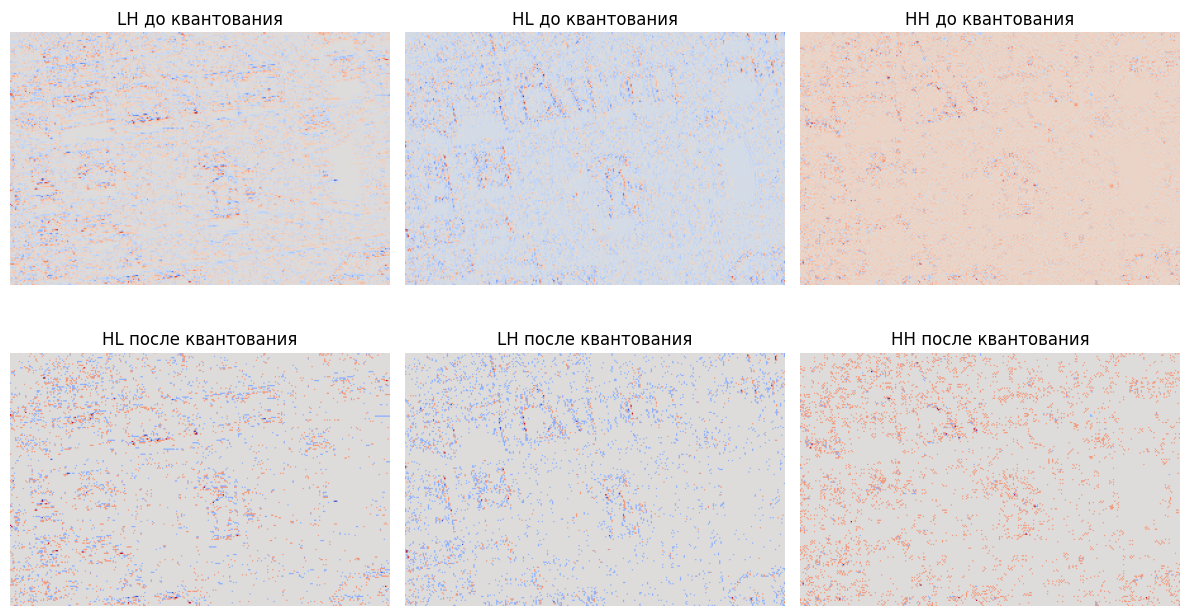

In [58]:
num_quants = 4
def quantize(coeffs, n_quants):
    min_val = np.min(coeffs)
    max_val = np.max(coeffs)
    step = (max_val - min_val) / n_quants
    quantized = np.round((coeffs - min_val) / step).astype(int)
    return quantized, min_val, step


lh_quantize, lh_min, lh_step = quantize(lh, num_quants)
hl_quantize, hl_min, hl_step = quantize(hl, num_quants)
hh_quantize, hh_min, hh_step = quantize(hh, num_quants)


def dequantize(quantized, min_val, step):
    return min_val + quantized * step


lh_restored = dequantize(lh_quantize, lh_min, lh_step)
hl_restored = dequantize(hl_quantize, hl_min, hl_step)
hh_restored = dequantize(hh_quantize, hh_min, hh_step)

plt.figure(figsize=(12, 10))
plt.subplot(3, 3, 1)
plt.imshow(lh, cmap='coolwarm')
plt.title('LH до квантования')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(hl, cmap='coolwarm')
plt.title('HL до квантования')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(hh, cmap='coolwarm')
plt.title('HH до квантования')
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(lh_restored, cmap='coolwarm')
plt.title('HL после квантования')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(hl_restored, cmap='coolwarm')
plt.title('LH после квантования')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(hh_restored, cmap='coolwarm')
plt.title('HH после квантования')
plt.axis('off')

plt.tight_layout()
plt.show()

In [59]:
def run_length_encode(data):
    encoded = []
    for value, count in Counter(data.flatten()).items():
        encoded.append((value, count))
    return encoded


lh_rle = run_length_encode(lh_quantize)
hl_rle = run_length_encode(hl_quantize)
hh_rle = run_length_encode(hh_quantize)

In [60]:
with open('haar_components.txt', 'w') as f:
    np.savetxt(f, ll, fmt='%d')
    f.write('\nLH:\n')
    for value, count in lh_rle:
        f.write(f"{value} {count}\n")
    f.write('\nHL:\n')
    for value, count in hl_rle:
        f.write(f"{value} {count}\n")
    f.write('\nHH:\n')
    for value, count in hh_rle:
        f.write(f"{value} {count}\n")
with open('monochrome_image.txt', 'r') as f:
    original_size = len(f.read().encode('utf-8'))

with open('haar_components.txt', 'r') as f:
    compressed_size = len(f.read().encode('utf-8'))

print(f"Исходное изображение: {original_size} байт")
print(f"Сжатое изображение: {compressed_size} байт")
print(f"Коэффициент сжатия: {original_size / compressed_size:.1f}")

Исходное изображение: 764822 байт
Сжатое изображение: 190896 байт
Коэффициент сжатия: 4.0
